In [59]:
from lsst.daf.butler import Butler
import numpy as np
from tqdm import tqdm
import os
import argparse
import pickle
os.environ["POLARS_MAX_THREADS"] = "1"
import polars
import matplotlib.pyplot as plt

In [2]:
repo = "dp2_prep"
collection = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage3"

In [3]:
butler = Butler(repo, collections=collection)
objectAll_dsrs = list(butler.registry.queryDatasets("object_all"))

In [22]:
tract_mapping = {}

for dsr in tqdm(objectAll_dsrs, desc="Building tract mapping"):
    tract = dsr.dataId["tract"]
    #band = dsr.dataId["band"]
    tract_mapping[tract] = {}

Building tract mapping: 100%|██████████| 2192/2192 [00:00<00:00, 2029561.67it/s]


In [71]:
band = "r"

# Columns to read from parquet files
PARQUET_COLUMNS = [
    f"{band}_calib_psf_used", "detect_isPrimary", "refExtendedness",
    f"{band}_pixelFlags_inexact_psfCenter", f'{band}_calib_psf_reserved',
    f"{band}_ixxPSF", f"{band}_iyyPSF", f"{band}_ixyPSF",
    f"{band}_ixx", f"{band}_iyy", f"{band}_ixy",
    f"{band}_ra", f"{band}_dec",
]

uri = butler.getURI("object_all", skymap='lsst_cells_v2', tract=6304)
parquet_path = uri.geturl()
table = polars.scan_parquet(parquet_path).select(PARQUET_COLUMNS).collect()

In [72]:
len(table)

559485

In [73]:
Filter = table['detect_isPrimary'].to_numpy() == True
Filter &= table['refExtendedness'].to_numpy() == 0.0 # keep stars only
Filter &= table[f'{band}_calib_psf_used'].to_numpy() == True # that were used to build the psf model
Filter &= table[f'{band}_pixelFlags_inexact_psfCenter'].to_numpy() == False # To avoid objects with discontinuous PSF (due to edges)

In [74]:
table_psf = table.filter(Filter)

In [75]:
slot_Shape_xx = table_psf[f"{band}_ixx"].to_numpy()
slot_Shape_yy = table_psf[f"{band}_iyy"].to_numpy()
slot_Shape_xy = table_psf[f"{band}_ixy"].to_numpy()
slot_PsfShape_xx = table_psf[f"{band}_ixxPSF"].to_numpy()
slot_PsfShape_yy = table_psf[f"{band}_iyyPSF"].to_numpy()
slot_PsfShape_xy = table_psf[f"{band}_ixyPSF"].to_numpy()
ra = table_psf[f"{band}_ra"].to_numpy()
dec = table_psf[f"{band}_dec"].to_numpy()

T_src = slot_Shape_xx + slot_Shape_yy
e1_src = (slot_Shape_xx - slot_Shape_yy) / T_src
e2_src = 2 * slot_Shape_xy / T_src

T_psf = slot_PsfShape_xx + slot_PsfShape_yy
e1_psf = (slot_PsfShape_xx - slot_PsfShape_yy) / T_psf
e2_psf = 2 * slot_PsfShape_xy / T_psf



([], [])

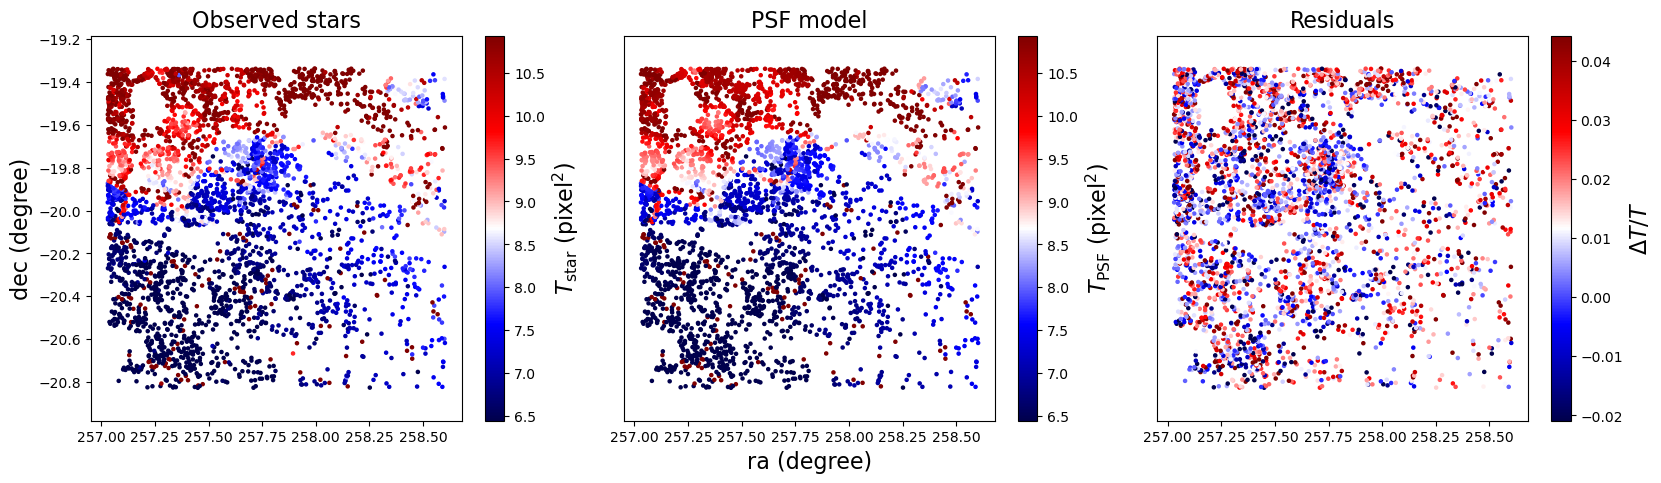

In [76]:
plt.figure(figsize=(18,5))
plt.subplots_adjust(wspace=0.15, right=0.9, left=0.05)

MIN = np.nanmean(T_src) - np.nanstd(T_src)
MAX = np.nanmean(T_src) + np.nanstd(T_src)

plt.subplot(1,3,1)

plt.scatter(ra, dec, s=5, c=T_src, vmin=MIN, vmax=MAX, cmap=plt.cm.seismic)
cb = plt.colorbar()
_ = plt.axis('equal')
cb.set_label('$T_{\\text{star}}$ (pixel$^2$)', fontsize=16)
plt.title('Observed stars', fontsize=16)
plt.ylabel('dec (degree)', fontsize=16)

plt.subplot(1,3,2)

plt.scatter(ra, dec, s=5, c=T_psf, vmin=MIN, vmax=MAX, cmap=plt.cm.seismic)
cb = plt.colorbar()
_ = plt.axis('equal')
cb.set_label('$T_{\\text{PSF}}$ (pixel$^2$)', fontsize=16)
plt.title('PSF model', fontsize=16)
plt.xlabel('ra (degree)', fontsize=16)
plt.yticks([],[])

plt.subplot(1,3,3)

residuals = (T_src - T_psf)/ T_src
MINR = np.nanmean(residuals) - np.nanstd(residuals)
MAXR = np.nanmean(residuals) + np.nanstd(residuals)

plt.scatter(ra, dec, s=5, c=(T_src - T_psf)/ T_src, cmap=plt.cm.seismic, vmin=MINR, vmax=MAXR)
cb = plt.colorbar()
_ = plt.axis('equal')
plt.title('Residuals', fontsize=16)
cb.set_label('$\\Delta T / T$', fontsize=16)
plt.yticks([],[])

#plt.savefig(f'single_visit_{visit}.png')

([], [])

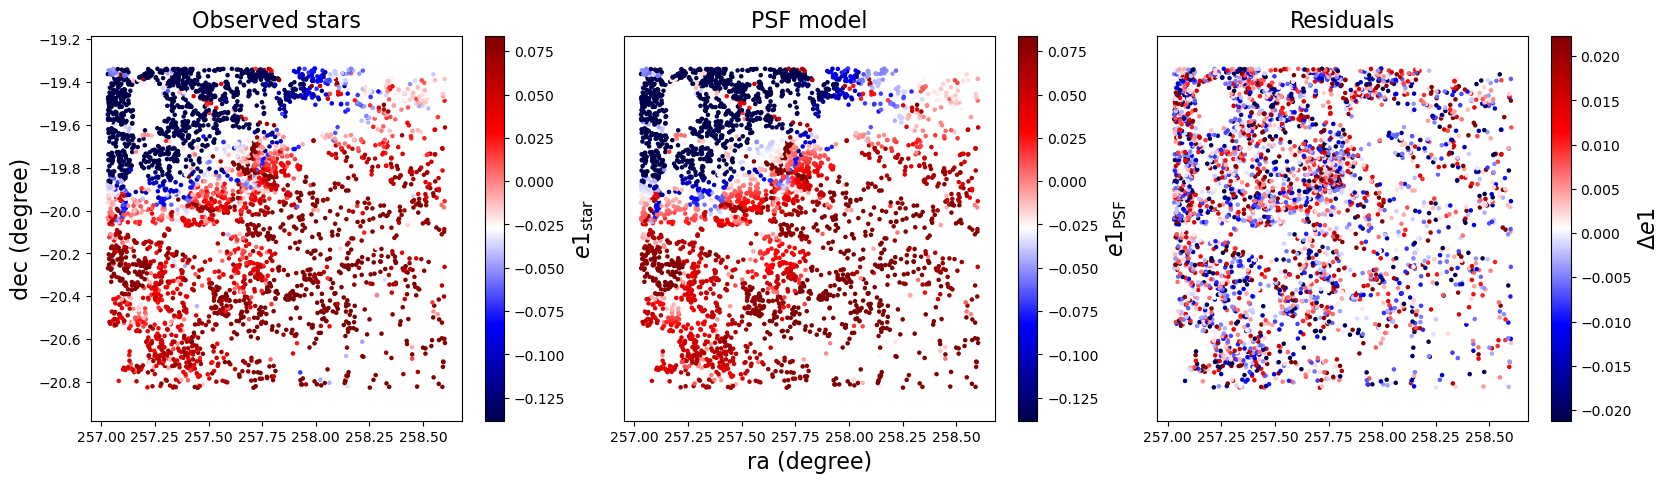

In [80]:
plt.figure(figsize=(18,5))
plt.subplots_adjust(wspace=0.15, right=0.9, left=0.05)

MIN = np.nanmean(e1_src) - np.nanstd(e1_src)
MAX = np.nanmean(e1_src) + np.nanstd(e1_src)

plt.subplot(1,3,1)

plt.scatter(ra, dec, s=5, c=e1_src, vmin=MIN, vmax=MAX, cmap=plt.cm.seismic)
cb = plt.colorbar()
_ = plt.axis('equal')
cb.set_label('$e1_{\\text{star}}$', fontsize=16)
plt.title('Observed stars', fontsize=16)
plt.ylabel('dec (degree)', fontsize=16)

plt.subplot(1,3,2)

plt.scatter(ra, dec, s=5, c=e1_psf, vmin=MIN, vmax=MAX, cmap=plt.cm.seismic)
cb = plt.colorbar()
_ = plt.axis('equal')
cb.set_label('$e1_{\\text{PSF}}$', fontsize=16)
plt.title('PSF model', fontsize=16)
plt.xlabel('ra (degree)', fontsize=16)
plt.yticks([],[])

plt.subplot(1,3,3)

residuals = (e1_src - e1_psf)
MINR = np.nanmean(residuals) - np.nanstd(residuals)
MAXR = np.nanmean(residuals) + np.nanstd(residuals)

plt.scatter(ra, dec, s=5, c=residuals, cmap=plt.cm.seismic, vmin=MINR, vmax=MAXR)
cb = plt.colorbar()
_ = plt.axis('equal')
plt.title('Residuals', fontsize=16)
cb.set_label('$\\Delta e1$', fontsize=16)
plt.yticks([],[])

#plt.savefig(f'single_visit_{visit}.png')

([], [])

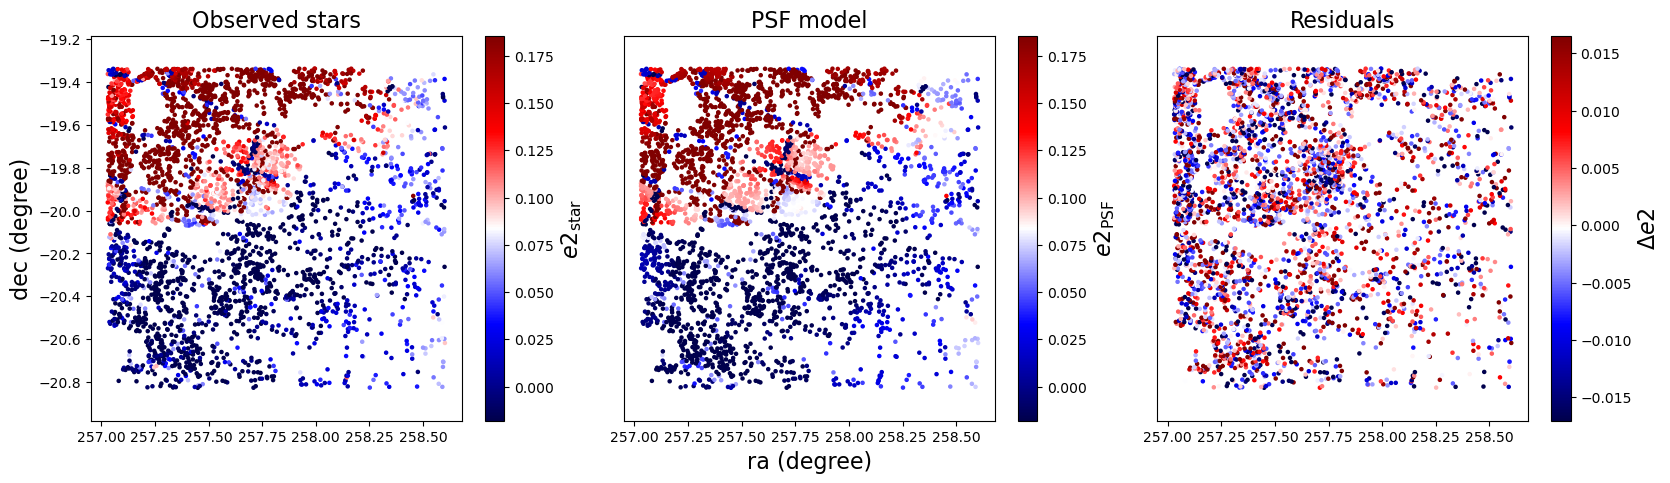

In [81]:
plt.figure(figsize=(18,5))
plt.subplots_adjust(wspace=0.15, right=0.9, left=0.05)

MIN = np.nanmean(e2_src) - np.nanstd(e2_src)
MAX = np.nanmean(e2_src) + np.nanstd(e2_src)

plt.subplot(1,3,1)

plt.scatter(ra, dec, s=5, c=e2_src, vmin=MIN, vmax=MAX, cmap=plt.cm.seismic)
cb = plt.colorbar()
_ = plt.axis('equal')
cb.set_label('$e2_{\\text{star}}$', fontsize=16)
plt.title('Observed stars', fontsize=16)
plt.ylabel('dec (degree)', fontsize=16)

plt.subplot(1,3,2)

plt.scatter(ra, dec, s=5, c=e2_psf, vmin=MIN, vmax=MAX, cmap=plt.cm.seismic)
cb = plt.colorbar()
_ = plt.axis('equal')
cb.set_label('$e2_{\\text{PSF}}$', fontsize=16)
plt.title('PSF model', fontsize=16)
plt.xlabel('ra (degree)', fontsize=16)
plt.yticks([],[])

plt.subplot(1,3,3)

residuals = (e2_src - e2_psf)
MINR = np.nanmean(residuals) - np.nanstd(residuals)
MAXR = np.nanmean(residuals) + np.nanstd(residuals)

plt.scatter(ra, dec, s=5, c=residuals, cmap=plt.cm.seismic, vmin=MINR, vmax=MAXR)
cb = plt.colorbar()
_ = plt.axis('equal')
plt.title('Residuals', fontsize=16)
cb.set_label('$\\Delta e2$', fontsize=16)
plt.yticks([],[])

#plt.savefig(f'single_visit_{visit}.png')

In [79]:
tract_mapping

{5390: {},
 2367: {},
 4743: {},
 2208: {},
 3740: {},
 2212: {},
 4331: {},
 3573: {},
 3943: {},
 2660: {},
 3199: {},
 3200: {},
 2534: {},
 3384: {},
 4345: {},
 4776: {},
 5404: {},
 4540: {},
 4976: {},
 5393: {},
 4777: {},
 5190: {},
 4969: {},
 5188: {},
 3201: {},
 2875: {},
 5406: {},
 3161: {},
 5062: {},
 3726: {},
 3176: {},
 4568: {},
 4749: {},
 5217: {},
 4578: {},
 4742: {},
 3946: {},
 2057: {},
 3536: {},
 5227: {},
 2055: {},
 3234: {},
 2701: {},
 3730: {},
 4771: {},
 4956: {},
 5396: {},
 5407: {},
 4546: {},
 2706: {},
 4124: {},
 4539: {},
 4766: {},
 4566: {},
 4758: {},
 5220: {},
 4545: {},
 5206: {},
 4750: {},
 2702: {},
 4551: {},
 2396: {},
 3727: {},
 2834: {},
 4848: {},
 3574: {},
 3359: {},
 3951: {},
 3571: {},
 2835: {},
 4363: {},
 3731: {},
 3733: {},
 4338: {},
 4970: {},
 5185: {},
 4138: {},
 4995: {},
 5180: {},
 3728: {},
 5395: {},
 2213: {},
 4554: {},
 4353: {},
 4996: {},
 4992: {},
 2236: {},
 4980: {},
 4957: {},
 2494: {},
 5183: {},